In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/Churn_Modelling.csv")
df.head(5)
df.info()
df["Exited"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Exited
0    7963
1    2037
Name: count, dtype: int64

In [2]:
df.groupby("Exited")["Age"].mean()  #yaş ortalamasına bakılır buna göre bir analiz yapılabilir


Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

In [3]:
df.groupby("Exited")["IsActiveMember"].mean()  #aktif üyelik oranına bakılır

Exited
0    0.554565
1    0.360825
Name: IsActiveMember, dtype: float64

In [4]:
df.groupby("Geography")["Exited"].mean()  #ülkelere göre churn oranına bakılır buna göre analiz yapılacak

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

In [5]:
df_model = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
#kalıcı silmedim çünkü bir hata olursa geri dönebilirim bu şekilde


In [6]:
df_model.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [7]:
df_model["Gender"] = df_model["Gender"].map({
    "Male":1,
    "Female":0
}
)  #gender sütunu için encoding yaptım

df_model["Gender"].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [8]:
df_model = pd.get_dummies(
    df_model,
    columns=["Geography"],
    drop_first=True
)

#one hot encoding yaptım geography sütunu için

In [9]:
y = df_model["Exited"]
X = df_model.drop("Exited", axis=1)

#target feature ayrımı yaptım

X.shape, y.shape

((10000, 11), (10000,))

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y  #imbalanced data için stratify kullanılır
)


In [11]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#scaling yani ölçekleme yaptım böylece sayısal featurelar aynı ölçeğe gelmiş oldu
#yani büyük sayılar ile küçük sayılar aynı seviyeye gelmiş oldu
#bu da modelin performansını artırır -> modelin büyük sayılara daha çok önem vermesini engeller

In [12]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [13]:
y_pred = log_model.predict(X_test_scaled)
y_pred[0:10]  #y_pred bir numpy array olduğu için head kullanılmaz

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm   #confusion matrix oluşturdum

array([[1540,   53],
       [ 331,   76]])

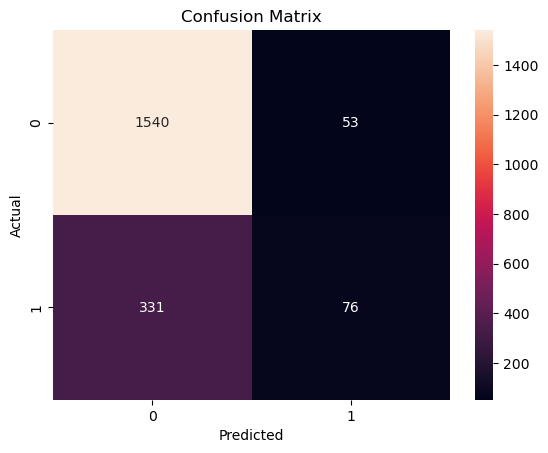

In [15]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d")  #annot ile hücre içine sayılar yazılır 
# fmt ile sayı formatı d-> integer f->float 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()  

In [16]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



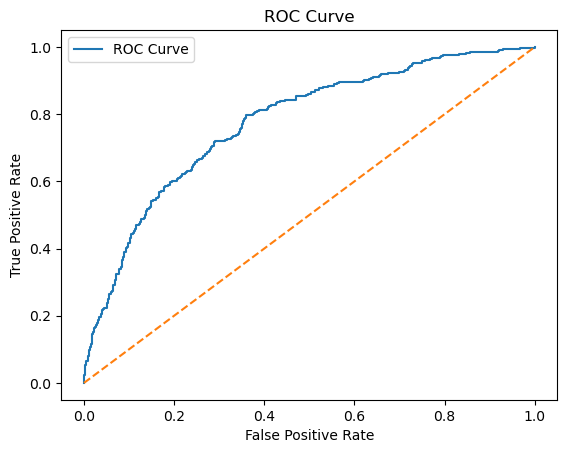

In [17]:
# ROC Curve ve AUC

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
y_prob = log_model.predict_proba(X_test_scaled)[:,1]  #predict_proba olasılık verir, predict direkt karar verir (0-1)
y_prob[0:10]  #müşterilerin churn etme olasılıkları

# Threshold = “churn demek için gereken minimum olasılık” 
roc_curve_data = roc_curve(y_test, y_prob) #bütün threshold değerlerini dener, üç liste olarak döndürür
fpr, tpr, thresholds = roc_curve_data #fpr: false positive rate, tpr: true positive rate

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_prob)     #test ile prob karşılaştırılır
print("AUC Score:", auc)


AUC Score: 0.7747778595236223


In [19]:
#Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight="balanced"  #?????
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
confusion_matrix(y_test, y_pred_dt)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1593
           1       0.43      0.75      0.54       407

    accuracy                           0.74      2000
   macro avg       0.67      0.75      0.68      2000
weighted avg       0.82      0.74      0.77      2000



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
confusion_matrix(y_test, y_pred_rf)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1593
           1       0.51      0.73      0.60       407

    accuracy                           0.80      2000
   macro avg       0.72      0.77      0.73      2000
weighted avg       0.84      0.80      0.81      2000

